In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

#the root-finding jacobian has boundary conditions of zero

@njit
def jacobian(u_n, h, N):
    J = np.zeros((N**2, N**2))
    
    for i in range(N):
        for j in range(N):
            k = i*N + j
            
            if i == 0 or i == N-1 or j == 0 or j == N-1:
                J[k,k] = 1
                continue
            
            J[k,k] = -4 - 4 * h**2 * u_n[k]**3
            
            J[k,k-1] = 1
            J[k,k+1] = 1
            J[k,k-N] = 1
            J[k,k+N] = 1
    
    return J / h**2

@njit
def f(u_n, h, N):
    R = np.zeros((N**2))
    
    for i in range(N):
        for j in range(N):
            k = i*N + j
            
            if i == 0 or i == N-1 or j == 0 or j == N-1:
                R[k] = u_n[k] - 1
                continue
            
            R[k] = (u_n[k-1] + u_n[k+1] + u_n[k-N] + u_n[k+N] - 4*u_n[k]) / h**2 - u_n[k]**4
    
    return R

Done.


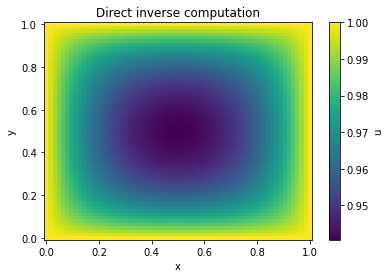

In [2]:
# PART B: directly compute inverse

N = 64
L = 1
h = L/N

x = np.linspace(0,1,N)
y = np.linspace(0,1,N)

# With Dirichlet, we implement BCs when we set the initial condition
u_old = np.ones((N**2,1)).flatten()

resid = 1
tol = 1e-9

while resid > tol:
    fUn = f(u_old, h, N)
    J = jacobian(u_old, h, N)
    Jinv = np.linalg.inv(J)
    Jinv_f = Jinv@fUn
    u_new = u_old - Jinv_f
    resid = np.max(abs(u_new-u_old))
    u_old = u_new
    
print('Done.')

u_final = np.reshape(u_new, (N,N))

plt.figure()
plt.pcolormesh(x,y,u_final, shading='auto')
plt.colorbar(label='u')
plt.title('Direct inverse computation')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [ ]:
# CODE BELOW IS JUST A DRAFT. CODE USED IS IN p1c.py

# PART C: Iterative method

from scipy.sparse import csr_matrix

def jacobi(J,f):
    shp = J.shape
    f_new = f.copy()
    maindiag = J.diagonal()
    
    tol = 1
    counter = 0
    
    while tol > 1e-7 and counter < 10000:
        
        f_old = f_new.copy()    
        
        f_new = (f - J @ f_old + maindiag * f_old) / maindiag
        
        tol = np.max( np.abs(f_new - f_old) )
        counter += 1
    
    Jinv_f = f_new
    #print(counter)
    
    return Jinv_f

N = 128
L = 1
h = L/N

x = np.linspace(0,1,N)
y = np.linspace(0,1,N)

# With Dirichlet, we implement BCs when we set the initial condition
u_old = np.ones((N**2,1)).flatten()

resid = 1
tol = 1e-2

while resid > tol:
    fUn = f(u_old, h, N)
    J = jacobian(u_old, h, N)
    J_sparse = csr_matrix(J)
    Jinv_f = jacobi(J_sparse,fUn)
    u_new = u_old - Jinv_f
    resid = np.max(abs(u_new-u_old))
    u_old = u_new
    print(resid)
    
print('Done.')

u_final = np.reshape(u_new, (N,N))

plt.figure()
plt.pcolormesh(x,y,u_final, shading='auto')
plt.colorbar(label='u')
plt.title('N=128 Iterative computation')

plt.show()